## Christian's Sandbox

### Import Libraries

In [3]:
# Code Block 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import geopandas as gpd
from shapely.geometry import Point

%matplotlib inline
pd.set_option('display.max_columns', 500)
plt.style.use('fivethirtyeight')

### Import Data

In [6]:
# Code Block 2
df = pd.read_csv('/Users/jenner/Desktop/DATA 6550/Module 4/data/mortgage_covenant_data.csv', dtype = {'census_tract': 'str'})
display(df.head())
df.info()

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
0,2023,27037060737,Race Not Available,6,185000.0,195000.0,NaN,6.125,40.37,73.48,10,0.0,False,NaN
1,2023,27141030504,Race Not Available,6,375000.0,385000.0,NaN,6.625,10.64,121.26,10,0.0,False,NaN
2,2023,27023950400,Race Not Available,6,105000.0,105000.0,NaN,6.125,8.92,90.13,10,0.0,False,NaN
3,2023,27171100101,Race Not Available,6,285000.0,285000.0,NaN,6.750,13.27,104.37,10,0.0,False,NaN
4,2023,27159480100,Race Not Available,6,175000.0,175000.0,NaN,6.875,5.87,82.22,10,0.0,False,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100931 entries, 0 to 100930
Data columns (total 14 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   activity_year                      100931 non-null  int64  
 1   census_tract                       99915 non-null   object 
 2   derived_race                       100931 non-null  object 
 3   action_taken                       100931 non-null  int64  
 4   loan_amount                        100931 non-null  float64
 5   property_value                     83491 non-null   float64
 6   income                             88200 non-null   float64
 7   interest_rate                      78125 non-null   float64
 8   tract_minority_population_percent  100931 non-null  float64
 9   tract_to_msa_income_percentage     100931 non-null  float64
 10  denial_reason-1                    100931 non-null  int64  
 11  covenant_count                     1009

In [8]:
# Code Block 3
df_hennepin = df[df['census_tract'].str[:5] == '27053'].copy()
print(df_hennepin.shape)
display(df_hennepin.head())
df_hennepin.info()

(22669, 14)


,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
19,2023,27053026822,Race Not Available,6,445000.0,455000.0,NaN,7.625,39.47,100.56,10,0.0,False,NaN
36,2023,27053012102,Race Not Available,6,265000.0,275000.0,NaN,3.250,29.71,98.77,10,68.0,False,Medium (51-100)
68,2023,27053026202,White,1,315000.0,425000.0,NaN,8.250,12.84,159.62,10,2.0,True,Low (1-50)
69,2023,27053027602,White,4,515000.0,NaN,210.0,NaN,11.59,113.96,10,76.0,False,Medium (51-100)
70,2023,27053006800,White,1,665000.0,785000.0,182.0,8.625,41.44,15.77,10,0.0,True,NaN


<class 'pandas.core.frame.DataFrame'>
Index: 22669 entries, 19 to 100922
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   activity_year                      22669 non-null  int64  
 1   census_tract                       22669 non-null  object 
 2   derived_race                       22669 non-null  object 
 3   action_taken                       22669 non-null  int64  
 4   loan_amount                        22669 non-null  float64
 5   property_value                     19023 non-null  float64
 6   income                             19545 non-null  float64
 7   interest_rate                      18069 non-null  float64
 8   tract_minority_population_percent  22669 non-null  float64
 9   tract_to_msa_income_percentage     22669 non-null  float64
 10  denial_reason-1                    22669 non-null  int64  
 11  covenant_count                     22669 non-null  float6

### Analysis

In [27]:
# Code Block 4
df_hennepin['derived_race'].value_counts(dropna = False)

derived_race
White                                        12767
Race Not Available                            5610
Black or African American                     1760
Asian                                         1642
Joint                                          683
American Indian or Alaska Native               147
2 or more minority races                        42
Native Hawaiian or Other Pacific Islander       18
Name: count, dtype: int64

In [31]:
# Code Block 5
df_hennepin = df_hennepin[(df_hennepin['derived_race'] != 'Race Not Available') & (df_hennepin['derived_race'] != 'Joint')]
df_hennepin['derived_race'].value_counts(dropna = False)

derived_race
White                                        12767
Black or African American                     1760
Asian                                         1642
American Indian or Alaska Native               147
2 or more minority races                        42
Native Hawaiian or Other Pacific Islander       18
Name: count, dtype: int64

I want to explore how different aspects of the data may be biased on the basis of race. By taking a brief look at the value counts in the data set, we can see that White is overly represented in the data set in a way that could be favorable.

#### Exploring Approval Rate by Covenant Status and Race

I want to see if a connection between Covenant Status and Race may be visible within a bar graph.

In [39]:
# Code Block 6
df_hennepin['has_covenant'] = df_hennepin['covenant_count'] > 0

approval = (df_hennepin.groupby(['derived_race', 'has_covenant'])
            ['was_approved'].mean()
            .unstack())

order = (df_hennepin.groupby('derived_race')['was_approved']
         .mean()
         .sort_values(ascending = False)
         .index)

approval = approval.loc[order]

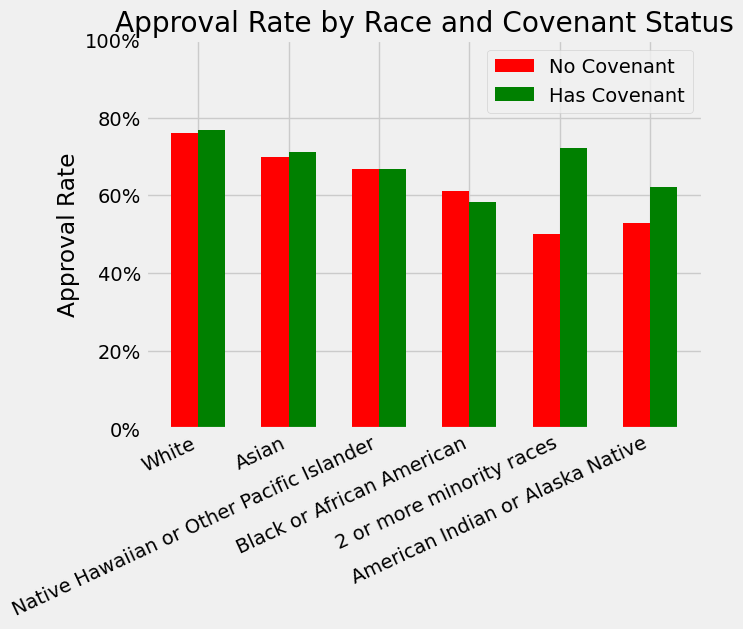

In [43]:
# Code Block 7
x = np.arange(len(approval))
bar_width = 0.3

plt.bar(x - bar_width/2, 
        approval[False], 
        width = bar_width,
        color = 'red',
        label = 'No Covenant')

plt.bar(x + bar_width/2, 
        approval[True], 
        width = bar_width,
        color = 'green',
        label = 'Has Covenant')

plt.xticks(x, approval.index, rotation = 25, ha = 'right')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.ylim(0,1)

plt.ylabel("Approval Rate")
plt.title("Approval Rate by Race and Covenant Status")
plt.legend()

plt.show()

#### Loan to Income Ratio by Approval Status and Race

I want to compare if minority races had higher denial rates that White applicants. I also want to see if any outliers greatly change how the graph looks.

In [47]:
# Code Block 8
df_hennepin = df_hennepin.dropna(subset = ['income'])

df_hennepin['loan_to_income'] = df_hennepin['loan_amount'] / (df_hennepin['income'] + 1)

outlier = df_hennepin['loan_to_income'].quantile(0.99)
df1 = df_hennepin[df_hennepin['loan_to_income'] < outlier].copy()

checked = df1['derived_race'].value_counts()
checked = checked[checked >= 30].index.tolist()
df1 = df1[df1['derived_race'].isin(checked)]

/var/folders/v0/c8l961l94ljf4c6jltfcp5l80000gn/T/ipykernel_45792/148235569.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_hennepin['loan_to_income'] = df_hennepin['loan_amount'] / (df_hennepin['income'] + 1)


In [49]:
# Code Block 9
df1_p = df1.groupby(['derived_race', 'was_approved'])['loan_to_income'].median()
df1_p = df1_p.unstack('was_approved')

df1_p = df1_p.sort_values(True)

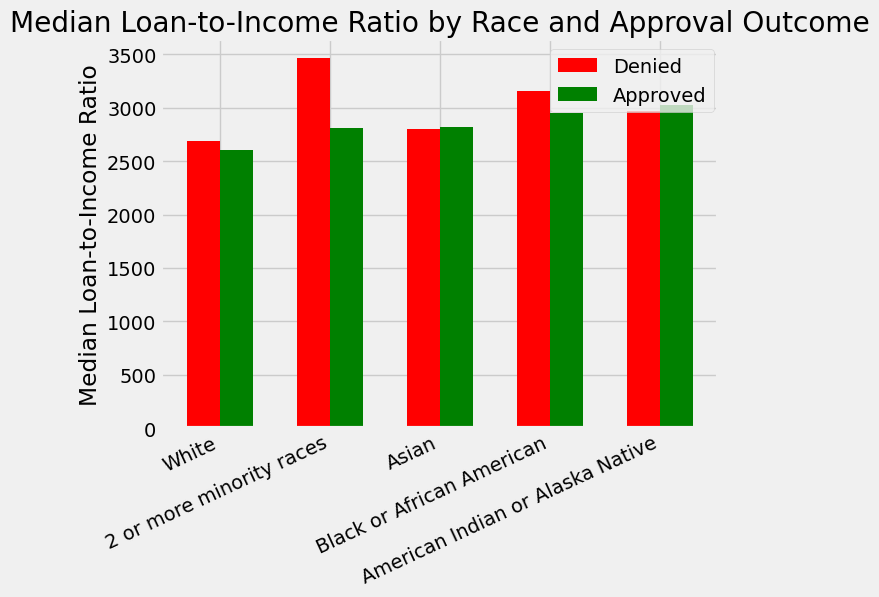

In [53]:
# Code Block 10
x = np.arange(len(df1_p))
bar_width = 0.3
 
plt.bar(x - bar_width/2,
        df1_p[False],
        width = bar_width,
        color = 'red',
        label = 'Denied')

plt.bar(x + bar_width/2,
        df1_p[True],
        width = bar_width,
        color = 'green',
        label = 'Approved')

plt.xticks(x, df1_p.index, rotation = 25, ha = 'right')

plt.ylabel('Median Loan-to-Income Ratio')
plt.title('Median Loan-to-Income Ratio by Race and Approval Outcome')
plt.legend(bbox_to_anchor = (1.01, 1), loc = 'upper right')

plt.show()

Now without the outliers removed.

In [56]:
# Code Block 11
df_hennepin['loan_to_income'] = df_hennepin['loan_amount'] / (df_hennepin['income'] + 1)

checked = df_hennepin['derived_race'].value_counts()
checked = checked[checked >= 30].index.tolist()
df2 = df_hennepin[df_hennepin['derived_race'].isin(checked)]

df2_p = df2.groupby(['derived_race', 'was_approved'])['loan_to_income'].median()
df2_p = df2_p.unstack('was_approved')

df2_p = df2_p.sort_values(True)

/var/folders/v0/c8l961l94ljf4c6jltfcp5l80000gn/T/ipykernel_45792/687089430.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_hennepin['loan_to_income'] = df_hennepin['loan_amount'] / (df_hennepin['income'] + 1)


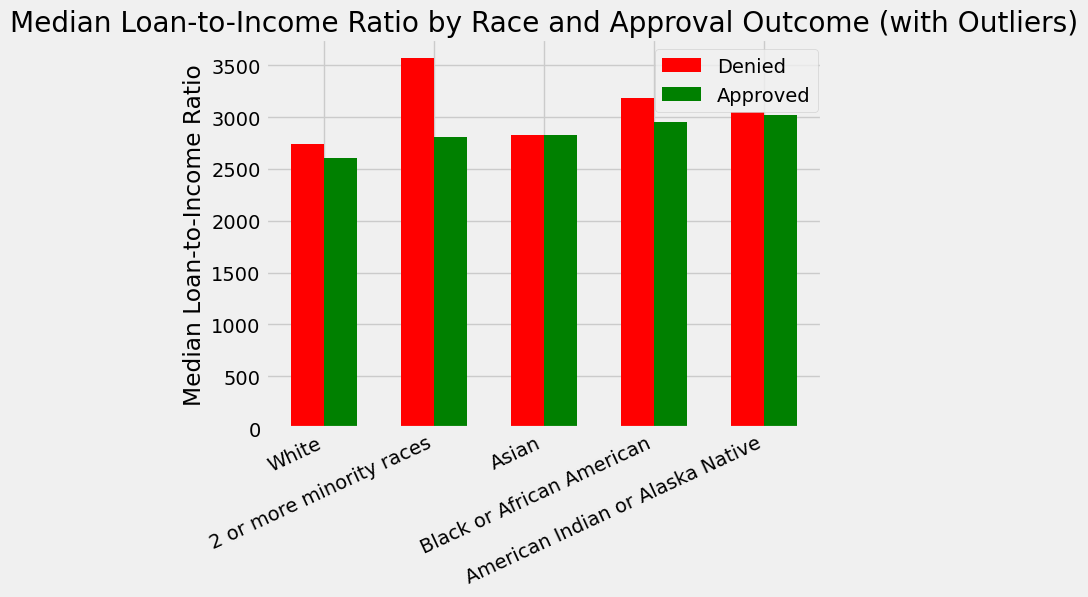

In [58]:
# Code Block 12
x = np.arange(len(df2_p))
bar_width = 0.3
 
plt.bar(x - bar_width/2,
        df2_p[False],
        width = bar_width,
        color = 'red',
        label = 'Denied')

plt.bar(x + bar_width/2,
        df2_p[True],
        width = bar_width,
        color = 'green',
        label = 'Approved')

plt.xticks(x, df2_p.index, rotation = 25, ha = 'right')

plt.ylabel('Median Loan-to-Income Ratio')
plt.title('Median Loan-to-Income Ratio by Race and Approval Outcome (with Outliers)')
plt.legend(bbox_to_anchor = (1.01, 1), loc = 'upper right')

plt.show()

It appears the groups most affected by the inclusion of outliers are 'American Indian or Alaska Native' and '2 or more minority races'.

#### Interest Rate by Race

I want to see if all groups receive similar interest rates. I will use the White race as the base because it is the most represented within the data set.

In [62]:
# Code Block 13
approved = df_hennepin[df_hennepin['was_approved'] == True].copy()
approved = approved[approved['interest_rate'].notna()]
approved = approved[approved['interest_rate'] > 0]
 
checked = approved['derived_race'].value_counts()
checked = checked[checked >= 30].index.tolist()
approved = approved[approved['derived_race'].isin(checked)]

In [64]:
# Code Block 14
median = approved.groupby('derived_race')['interest_rate'].median().sort_values()
w_median = median['White']

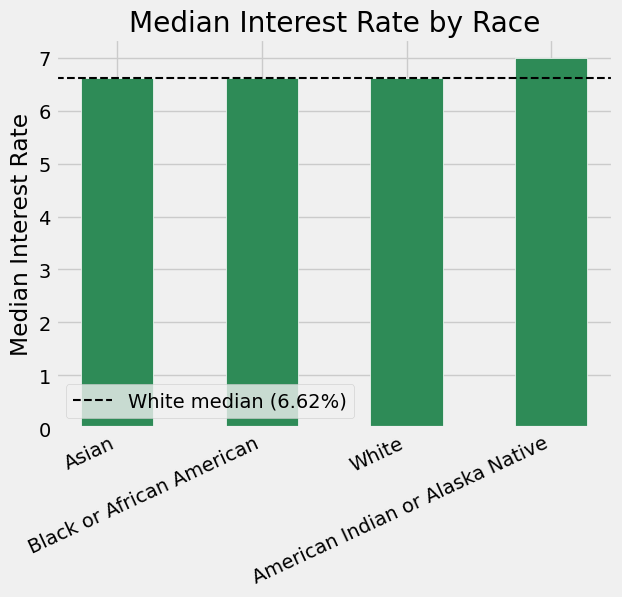

In [66]:
# Code Block 15
x = np.arange(len(median))
 
plt.bar(x,
        median,
        width = 0.5,
        color = 'seagreen',
        edgecolor = 'white')

plt.axhline(w_median,
            color = 'black',
            linestyle = '--',
            linewidth = 1.5,
            label = f'White median ({w_median:.2f}%)')

plt.xticks(x, median.index, rotation = 25, ha = 'right')

plt.ylabel('Median Interest Rate')
plt.title('Median Interest Rate by Race')
plt.legend()

plt.show()

Here we see interest rates for 'American Indian or Alaska Native' is above the average.